=== CRÉATION DES FENÊTRES TEMPORELLES (Sliding Windows) ===

Taille de la fenêtre     : 60 points temporels
Stride (pas)            : 10 points
Chevauchement           : 50 points

Nombre de fichiers originaux trouvés : 28



Création des fenêtres: 100%|███████████████████| 28/28 [00:05<00:00,  4.69it/s]



✓ FENÊTRES TEMPORELLES CRÉÉES AVEC SUCCÈS !
Nombre total de fenêtres créées : 70,687
Shape de X_windows : (70687, 60, 38)  →  (nombre_fenêtres, 60, 38)
Nombre de machines représentées : 28

Fichiers sauvegardés dans : data/processed/windows/
   • X_windows.npy
   • machine_info.npy

Statistiques détaillées :
Nombre de machines : 28
Fenêtres par machine en moyenne : 2524.5


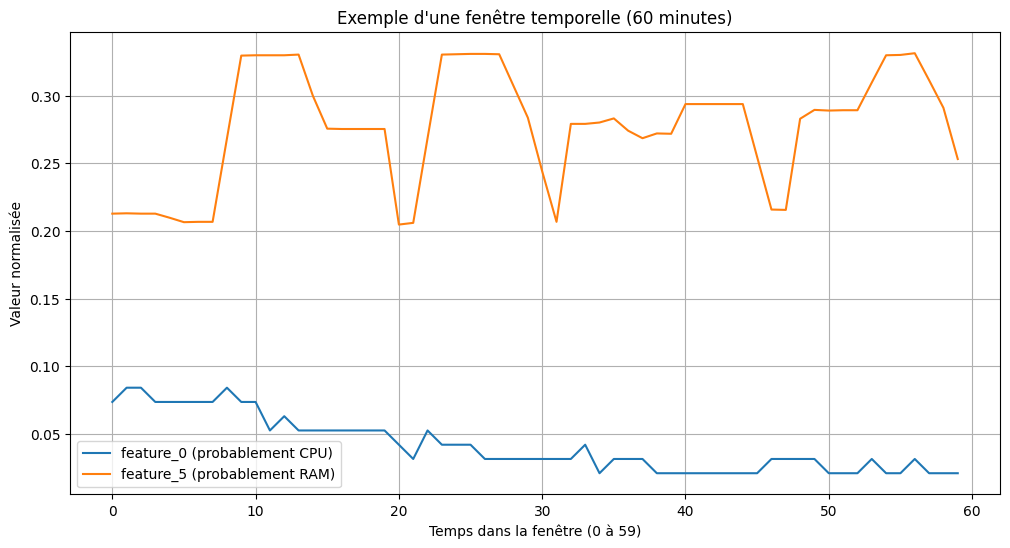


Prochaine étape : Charger les labels d'anomalies et construire le modèle


In [3]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

print("=== CRÉATION DES FENÊTRES TEMPORELLES (Sliding Windows) ===\n")

# ==================== PARAMÈTRES ====================
PROCESSED_PATH = 'data/processed/'
WINDOW_SIZE = 60          # 60 minutes = 1 heure (tu peux modifier)
STRIDE = 10               # On avance de 10 minutes à chaque fenêtre
OUTPUT_PATH = 'data/processed/windows/'

os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Taille de la fenêtre     : {WINDOW_SIZE} points temporels")
print(f"Stride (pas)            : {STRIDE} points")
print(f"Chevauchement           : {WINDOW_SIZE - STRIDE} points\n")

# Récupérer uniquement les fichiers originaux
files = [f for f in os.listdir(PROCESSED_PATH) if f.endswith('_original.npy')]

print(f"Nombre de fichiers originaux trouvés : {len(files)}\n")

X_windows = []
machine_info = []

for file in tqdm(files, desc="Création des fenêtres"):
    data = np.load(os.path.join(PROCESSED_PATH, file))
    machine_name = file.replace('_original.npy', '')
    
    # Création des fenêtres glissantes
    for i in range(0, len(data) - WINDOW_SIZE + 1, STRIDE):
        window = data[i:i + WINDOW_SIZE]           # Fenêtre de 60 x 38
        X_windows.append(window)
        machine_info.append(machine_name)

# Conversion en numpy array
X_windows = np.array(X_windows)
machine_info = np.array(machine_info)

print("\n" + "="*70)
print("✓ FENÊTRES TEMPORELLES CRÉÉES AVEC SUCCÈS !")
print(f"Nombre total de fenêtres créées : {X_windows.shape[0]:,}")
print(f"Shape de X_windows : {X_windows.shape}  →  (nombre_fenêtres, {WINDOW_SIZE}, 38)")
print(f"Nombre de machines représentées : {len(np.unique(machine_info))}")
print("="*70)

# ====================== SAUVEGARDE ======================
np.save(os.path.join(OUTPUT_PATH, 'X_windows.npy'), X_windows)
np.save(os.path.join(OUTPUT_PATH, 'machine_info.npy'), machine_info)

print(f"\nFichiers sauvegardés dans : {OUTPUT_PATH}")
print("   • X_windows.npy")
print("   • machine_info.npy")

# ====================== STATISTIQUES ======================
print("\nStatistiques détaillées :")
unique_machines = np.unique(machine_info)
print(f"Nombre de machines : {len(unique_machines)}")
print(f"Fenêtres par machine en moyenne : {X_windows.shape[0] / len(unique_machines):.1f}")

# Visualisation d'une fenêtre exemple
plt.figure(figsize=(12, 6))
plt.plot(X_windows[0, :, 0], label='feature_0 (probablement CPU)')
plt.plot(X_windows[0, :, 5], label='feature_5 (probablement RAM)')
plt.title('Exemple d\'une fenêtre temporelle (60 minutes)')
plt.xlabel('Temps dans la fenêtre (0 à 59)')
plt.ylabel('Valeur normalisée')
plt.legend()
plt.grid(True)
plt.show()

print("\nProchaine étape : Charger les labels d'anomalies et construire le modèle")